[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mento-calc/mento/blob/main/docs/source/examples/shear_wall_design_ACI_318-19_imperial.ipynb)

In [1]:
# Google Colab does not ship mento, so install it when running there.
# Guarded so that building the documentation never shells out to pip.
import sys

if "google.colab" in sys.modules:
    %pip install mento

# Shear Wall design ACI 318-19 (US customary units)

The same example in US customary units. A concrete given in `psi` makes the section US customary, and everything mento prints follows: in, in², in²/ft, psi, ksi, kip and kip·ft, with bars named by their ASTM size (`#5`) and spacings after an `@`. See [Units](../user_guide/units.rst#us-customary-output).

**Define concrete and steel materials, and then assign the shear wall**

In [2]:
from mento import Concrete_ACI_318_19, SteelBar, ShearWall, psi, ksi, inch, ft, kip
from mento import Forces, Node

# Define materials
concrete = Concrete_ACI_318_19(name="4000 psi", f_c=4000 * psi)
steel = SteelBar(name="Grade 60", f_y=60 * ksi)

# Define wall geometry:
wall = ShearWall(
    label="W101",
    concrete=concrete,
    steel_bar=steel,
    thickness=10 * inch,
    length=13 * ft,
    height=11.5 * ft,
    c_c=0.75 * inch,
)
wall.data

Shear Wall W101, $l_w$=13.00 ft, $t$=10.00 in, $h_w$=11.50 ft, $c_c$=0.75 in, Concrete 4000 psi, Rebar Grade 60.

**Define list of forces applied to the wall and create node**

In [3]:
# Define forces acting on the wall
f1 = Forces(label="1.2D+1.0E", V_z=180 * kip)
f2 = Forces(label="0.9D+1.0E", V_z=110 * kip)
# Create node with wall and forces
node_1 = Node(section=wall, forces=[f1, f2])
node_1

Node ID: 1 - Section label: W101
Forces Applied:
  - Force ID: 1, Label: 1.2D+1.0E, N_x: 0.00 kip, V_z: 180.00 kip, M_y: 0.00 ft⋅kip
  - Force ID: 2, Label: 0.9D+1.0E, N_x: 0.00 kip, V_z: 110.00 kip, M_y: 0.00 ft⋅kip

**Perform shear design**

In [4]:
# Perform design
node_1.design()
# Print results in Markdown format
node_1.results

Shear Wall W101, $l_w$=13.00 ft, $t$=10.00 in, $h_w$=11.50 ft, $c_c$=0.75 in, Concrete 4000 psi, Rebar Grade 60.

Horizontal rebar: #3@8 in E.F., $\rho_t$=0.00276, Minimum vertical rebar: #3@8 in E.F., $\rho_l$=0.00276, $V_u$=180 kip, $\phi V_n$=415.83 kip → $\color{#439b00}{\text{DCR}=0.43}$ 

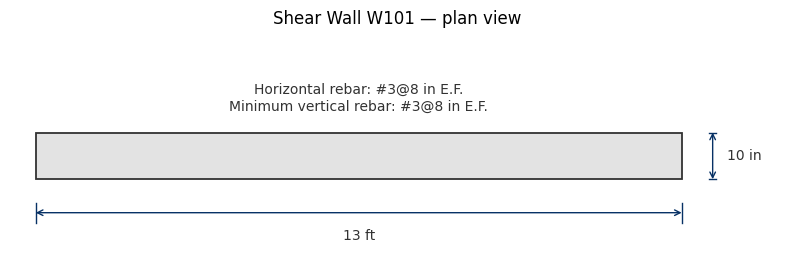

In [5]:
# Plot the wall geometry and reinforcement
wall.plot()

In [6]:
# Print shear results in more detailed format in a DataFrame
node_1.check_shear()

,Label,Comb.,"ρt,min","ρt,req",ρt,"ρl,min",ρl,Vu,ØVc,ØVs,ØVn,"ØVn,max","Vu≤ØVn,max",Vu≤ØVn,DCR
0,,,,,,,,kip,kip,kip,kip,kip,,,
1,W101,1.2D+1.0E,0.0025,0.0025,0.00276,0.0025,0.00276,180,221.99,193.83,415.83,591.98,True,True,0.433
2,W101,0.9D+1.0E,0.0025,0.0025,0.00276,0.0025,0.00276,110,221.99,193.83,415.83,591.98,True,True,0.265


**Export table results to Excel**

In [7]:
node_1.check_shear().to_excel("ACI 318-19 US shear_wall_results.xlsx")

**View complete and detailed results for the limiting case of the list of forces**

In [8]:
# View detailed shear results
node_1.shear_results_detailed()

===== SHEAR WALL DETAILED RESULTS =====
Materials                            Variable     Value  Unit
----------------------------------  ----------  -------  ------
Section Label                                      W101
Concrete strength                       fc         4000  psi
Steel reinforcement yield strength      fy           60  ksi
Normalweight concrete                   λ             1
Safety factor for shear                 Øv         0.75 

Geometry           Variable     Value  Unit
----------------  ----------  -------  ------
Wall thickness        t            10  in
Wall length           lw           13  ft
Wall height           hw         11.5  ft
Aspect ratio        hw/lw       0.885
Gross shear area     Acv         1560  in² 

Design forces     Variable     Value  Unit
---------------  ----------  -------  ------
Shear                Vu          180  kip 

Check                            Unit     Value  Min.      Max.  Ok?
------------------------------  ------  --

**Export detailed results to a Word document**

In [9]:
node_1.shear_results_detailed_doc()